<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/MachineLearning/ML_AprendizadoSupervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Objetivo: Aprendizado Supervisionado
O aprendizado é guiado por um "gabarito". A IA aprende a mapear uma entrada (Altura) para uma saída específica (Cavalo/Não Cavalo).

## Aplicar conceitos de Machine Learning (ML), utilizando:
- **Aprendizado Supervisionado:** Uso de dados rotulados (Cavalos vs. Outros) extraídos de frames de vídeo.
- **Classificação Binária:** Modelo treinado para identificar se é um "Cavalo" com base na altura. O cavalo é o bicho mais alto entre os demais.
- **Engenharia de Features:** Extração da altura dos espécimes como variável principal de decisão.
- **Análise de Performance:** Geração de métricas (Acurácia, Precisão e Recall) e visualização da Fronteira de Decisão e gráfico Loss.
# Algoritmo de treino usado:
- Supervisionado = Perceptron: Um neurônio que precisa que diga o que é certo e o que é errado (gabarito) para ele aprender a separar as classes.

In [ ]:
# descompacta pasta
!unzip -q cavalos.zip -d /content/cavalos_data
!unzip -q outros.zip -d /content/outros_data

In [ ]:
# coletar dados
# extraindo frames dos videos (videos e apenas uma pilha de imagens)
import cv2
import os

# Configurar onde estão os vídeos e onde salvar as fotos
pasta_videos = '/content/cavalos_data/cavalos'
pasta_destino = '/content/dataset/cavalos'
os.makedirs(pasta_destino, exist_ok=True)

# Lista todos os arquivos da pasta
arquivos = os.listdir(pasta_videos)

for nome_arquivo in arquivos:
    # Caminho completo do vídeo
    caminho_completo = os.path.join(pasta_videos, nome_arquivo)

    # Abre o vídeo
    video = cv2.VideoCapture(caminho_completo)

    # Tira o primeiro frame (sucesso = True/False, imagem = os pixels)
    sucesso, imagem = video.read()

    if sucesso:
        #  Salva a imagem com um nome novo
        nome_foto = nome_arquivo + ".jpg"
        caminho_salvamento = os.path.join(pasta_destino, nome_foto)
        cv2.imwrite(caminho_salvamento, imagem)
        print(f"Sucesso: {nome_foto} extraído!")

    video.release()

Sucesso: 2.mp4.jpg extraído!
Sucesso: 4.mp4.jpg extraído!
Sucesso: 1.mp4.jpg extraído!
Sucesso: 5.mp4.jpg extraído!
Sucesso: 6.mp4.jpg extraído!
Sucesso: 10.mp4.jpg extraído!
Sucesso: 9.mp4.jpg extraído!
Sucesso: 3.mp4.jpg extraído!
Sucesso: 8.mp4.jpg extraído!
Sucesso: 7.mp4.jpg extraído!


In [1]:
# escolha de features - altura_estimada/peso_estimado
# Coluna 1: Altura Estimada (em metros)

# matriz de atributos
feacture = [
    # cavalos
    [1.80, 450], [1.85, 480], [1.82, 470], [1.82, 465], [1.91, 510],
    [1.80, 455], [1.85, 490], [1.90, 505], [1.88, 495], [1.80, 460],
    # outros
    [1.60, 150], [1.60, 145], [1.20, 80], [1.00, 40], [1.60, 155],
    [1.40, 110], [0.60, 15], [0.75, 30], [0.50, 12], [0.60, 18]
]

# resposta binaria para classificação 1 cavalo / 0 outros
resposta_classificacao = [1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0]


### Por que usamos Loop e Épocas no Aprendizado Supervisionado?

No aprendizado supervisionado com redes neurais (PyTorch), o modelo aprende por **Tentativa e Erro**.

1. **O Alvo:** O modelo tem um gabarito (`resposta_classificacao`). Ele sabe exatamente onde precisa chegar.
2. **O Processo (Épocas):** A cada época, o neurônio faz um "chute". Ele calcula o erro comparando o chute com a resposta real.
3. **O Ajuste (Otimizador):** O otimizador (`SGD` ou `Adam`) usa esse erro para ajustar o "peso" do neurônio aos poucos.
4. **O Loop:** Como o ajuste é milimétrico, precisamos repetir o processo centenas de vezes (épocas) até que o erro seja o menor possível e o neurônio "aprenda" a fronteira de decisão.

**Resumo:** O loop é necessário para o refinamento gradual do acerto baseado no gabarito.

In [2]:
# treinar classificador
# escolher algoritmo
# PyTorch - montando neuronio - perceptron
import torch
import torch.nn as redesNeurais

# PyTorch usa tensores(matrizes para numeros) e não listas
alturasPossiveis = torch.tensor(feacture, dtype=torch.float32)

# O .reshape(-1, 1) transforma a lista [0, 1, 0...] em uma coluna de 20 linhas e 1 coluna
classificacaoPossivel = torch.tensor(resposta_classificacao, dtype=torch.float32).reshape(-1, 1)

# Crio modelo (um neurônio simples) camada linear que aceita 2 entrada e 1 saida
modelo = redesNeurais.Linear(2, 1)

# Otimizador (O "ajudante" que vai girar os parafusos para o erro diminuir)
otimizador = torch.optim.SGD(modelo.parameters(), lr=0.1)

historico_erro = []

# Loop treinamento
for epoca in range(600):
    # Zera os ajustes anteriores para não acumular lixo
    otimizador.zero_grad()

    # Previsão: O modelo tenta adivinhar baseado nas alturas - sao os chutes
    previsao = modelo(alturasPossiveis)

    # Cálculo do erro (LOSS): Compara o que a IA chutou com a classificação real
    erro = redesNeurais.functional.binary_cross_entropy_with_logits(previsao, classificacaoPossivel)

    # Backward: O PyTorch descobre quem errou (ajuste do peso)
    erro.backward()

    # Step: O otimizador aplica o ajuste nos neurônios
    otimizador.step()

    # Guarda o erro da época atual na lista
    historico_erro.append(erro.item())

# neuronio entraga no fim do loop numero decimal Logit "infinito", necessario conversão para ver classificacao por posicao
# sigmoid - tranforma em %(O tradutor de humanos)
# decisao - se for > que confiança
with torch.no_grad():
    # Pegamos os chutes finais, aplicamos Sigmoid e transformamos em 0 ou 1
    confianca = torch.sigmoid(modelo(alturasPossiveis))
    predicoes_finais = (confianca >= 0.5).float().numpy()

print("Treinamento finalizado!")


Treinamento finalizado!


In [3]:
# Exibindo o array de predições da IA para as 20 posições
# Usamos .astype(int) para tirar o ".0" e facilitar a leitura
resultado_ia = predicoes_finais.flatten().astype(int)

print(f"\nResultado da Classificação para cada posição (20 ao todo):")
print(resultado_ia)

# Verificação rápida: Se o modelo estiver perfeito, os 10 primeiros são 1 e os 10 últimos 0
print(f"Total de Cavalos identificados: {sum(resultado_ia == 1)}")
print(f"Total de Outros identificados: {sum(resultado_ia == 0)}")


Resultado da Classificação para cada posição (20 ao todo):
[1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
Total de Cavalos identificados: 10
Total de Outros identificados: 10


In [4]:
# Relatório de Métricas (Acurácia, Precisão, Recall)
# avaliar modelo de classificação
# Importando as ferramentas de métricas (scikit-learn)
from sklearn.metrics import classification_report, accuracy_score
modelo.eval()
with torch.no_grad():
    previsoes_brutas = modelo(alturasPossiveis)
    # Aplica a Sigmoid para ter a "Confiança" (0 a 1)
    confianca = torch.sigmoid(previsoes_brutas)
    # Se confiança > 0.5, vira 1 (Cavalo), senão 0 (Outros)
    predicoes_finais = (confianca >= 0.5).float().numpy()

# Calcula a Acurácia
acuracia = accuracy_score(resposta_classificacao, predicoes_finais)

print(f"--- AVALIAÇÃO DO CLASSIFICADOR ---")
print(f"Acurácia Geral: {acuracia:.2%}")
print("\nRelatório Detalhado:")
print(classification_report(resposta_classificacao, predicoes_finais, target_names=['Outros', 'Cavalos']))

--- AVALIAÇÃO DO CLASSIFICADOR ---
Acurácia Geral: 100.00%

Relatório Detalhado:
              precision    recall  f1-score   support

      Outros       1.00      1.00      1.00        10
     Cavalos       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



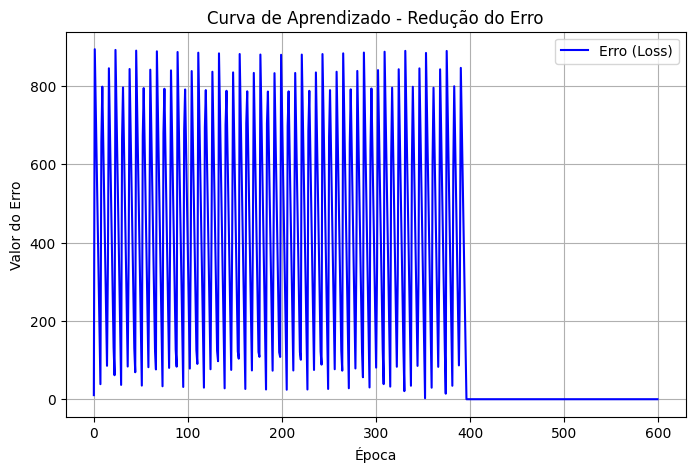

In [5]:
# Criando o Gráfico de Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(historico_erro, color='blue', label='Erro (Loss)')
plt.title('Curva de Aprendizado - Redução do Erro')
plt.xlabel('Época')
plt.ylabel('Valor do Erro')
plt.legend()
plt.grid(True)
plt.show()

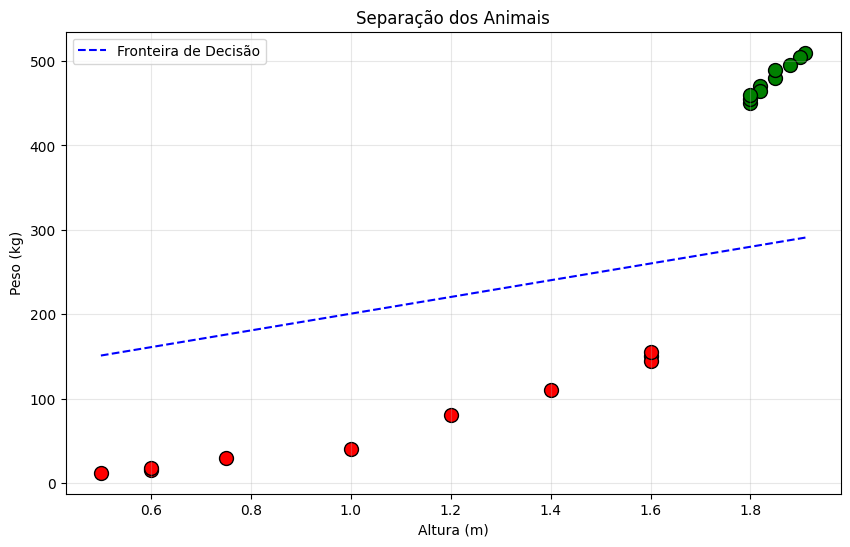

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparando os dados para o gráfico
# (Ajustado para os nomes que você está usando no seu treino)
dados_plot = alturasPossiveis.numpy()
respostas_plot = classificacaoPossivel.numpy().flatten()

alturas = dados_plot[:, 0]
# Se você tiver 2 colunas, a segunda é o peso.
# Se ainda estiver testando só com 1, o gráfico 2D vai precisar que a gente defina o que é o Eixo Y.
pesos = dados_plot[:, 1] if dados_plot.shape[1] > 1 else np.zeros_like(alturas)

plt.figure(figsize=(10, 6))

# 2. Plotando os pontos
for i in range(len(alturas)):
    cor = 'green' if respostas_plot[i] == 1 else 'red'
    plt.scatter(alturas[i], pesos[i], color=cor, s=100, edgecolors='k')

# 3. Pegando os pesos que a IA aprendeu
pesos_modelo = modelo.weight.data[0].numpy()
vies = modelo.bias.item()

# Lógica para desenhar a linha dependendo de quantas entradas você usou (1 ou 2)
if len(pesos_modelo) > 1:
    w1, w2 = pesos_modelo
    x_fronteira = np.linspace(alturas.min(), alturas.max(), 100)
    y_fronteira = -(w1 * x_fronteira + vies) / w2
    plt.plot(x_fronteira, y_fronteira, color='blue', linestyle='--', label='Fronteira de Decisão')
    plt.ylabel("Peso (kg)")
else:
    w1 = pesos_modelo[0]
    fronteira_vertical = -vies / w1
    plt.axvline(x=fronteira_vertical, color='blue', linestyle='--', label='Fronteira Linear')
    plt.ylabel("Visualização (Y=0)")

plt.title("Separação dos Animais")
plt.xlabel("Altura (m)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()